In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_excel('/content/Marketplace_Logistics_Sr. Exec_Assignment.xlsx', sheet_name='Dataset', header=2)
df.head()

,Order ID,Platform,Warehouse Location,Order Units,Order Weight (kgs),Transportation Cost (per kg),Stickering Requirement (Y/N),Stickering Cost per Unit (₹),Transit Time (days),Appointment Date,Appointment Adherence (Y/N),Penalty Cost (₹),Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,O00001,Flipkart,Mumbai,25668,2852.00,8,N,0,10,2025-01-10,N,4088,NaN,NaN,Stickering Time,2 minutes per unit for 1 manpower
1,O00002,Nykaa,Mumbai,3954,329.50,11,N,0,8,2025-01-20,N,2159,NaN,NaN,Shift Time,8 hours
2,O00003,Blinkit,Bangalore,352,29.36,10,N,0,5,2025-01-13,N,0,NaN,NaN,Number of shifts per day,2
3,O00004,Myntra,Bangalore,3552,296.00,17,N,0,7,2025-01-15,N,4105,NaN,NaN,NaN,NaN
4,O00005,Purplle,Delhi,1444,180.50,12,N,0,9,2025-01-28,N,0,NaN,NaN,NaN,NaN


In [4]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape (rows, columns): (100, 16)

Column names:
['Order ID', 'Platform', 'Warehouse Location', 'Order Units', 'Order Weight (kgs)', 'Transportation Cost (per kg)', 'Stickering Requirement (Y/N)', 'Stickering Cost per Unit (₹)', 'Transit Time (days)', 'Appointment Date', 'Appointment Adherence (Y/N)', 'Penalty Cost (₹)', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']


In [5]:
data_cols = ['Order ID', 'Platform', 'Warehouse Location', 'Order Units',
             'Order Weight (kgs)', 'Transportation Cost (per kg)',
             'Stickering Requirement (Y/N)', 'Stickering Cost per Unit (₹)',
             'Transit Time (days)', 'Appointment Date',
             'Appointment Adherence (Y/N)', 'Penalty Cost (₹)']

df = df[data_cols]

print("New shape:", df.shape)
df.head()

New shape: (100, 12)


,Order ID,Platform,Warehouse Location,Order Units,Order Weight (kgs),Transportation Cost (per kg),Stickering Requirement (Y/N),Stickering Cost per Unit (₹),Transit Time (days),Appointment Date,Appointment Adherence (Y/N),Penalty Cost (₹)
0,O00001,Flipkart,Mumbai,25668,2852.00,8,N,0,10,2025-01-10,N,4088
1,O00002,Nykaa,Mumbai,3954,329.50,11,N,0,8,2025-01-20,N,2159
2,O00003,Blinkit,Bangalore,352,29.36,10,N,0,5,2025-01-13,N,0
3,O00004,Myntra,Bangalore,3552,296.00,17,N,0,7,2025-01-15,N,4105
4,O00005,Purplle,Delhi,1444,180.50,12,N,0,9,2025-01-28,N,0


In [6]:
df['Transportation Cost (₹)'] = df['Order Weight (kgs)'] * df['Transportation Cost (per kg)']
df[['Order ID', 'Order Weight (kgs)', 'Transportation Cost (per kg)', 'Transportation Cost (₹)']].head()

,Order ID,Order Weight (kgs),Transportation Cost (per kg),Transportation Cost (₹)
0,O00001,2852.00,8,22816.0
1,O00002,329.50,11,3624.5
2,O00003,29.36,10,293.6
3,O00004,296.00,17,5032.0
4,O00005,180.50,12,2166.0


In [7]:
df['Stickering Cost (₹)'] = np.where(
    df['Stickering Requirement (Y/N)'] == 'Y',
    df['Order Units'] * df['Stickering Cost per Unit (₹)'],
    0
)

df[['Order ID', 'Platform', 'Stickering Requirement (Y/N)', 'Order Units', 'Stickering Cost per Unit (₹)', 'Stickering Cost (₹)']].head(20)

,Order ID,Platform,Stickering Requirement (Y/N),Order Units,Stickering Cost per Unit (₹),Stickering Cost (₹)
0,O00001,Flipkart,N,25668,0,0
1,O00002,Nykaa,N,3954,0,0
2,O00003,Blinkit,N,352,0,0
3,O00004,Myntra,N,3552,0,0
4,O00005,Purplle,N,1444,0,0
5,O00006,Myntra,N,1748,0,0
6,O00007,Zepto,N,298,0,0
7,O00008,Blinkit,N,390,0,0
8,O00009,Nykaa,N,2030,0,0
9,O00010,Myntra,N,4469,0,0


In [8]:
df['Total Logistics Cost (₹)'] = (df['Transportation Cost (₹)'] +
                                   df['Stickering Cost (₹)'] +
                                   df['Penalty Cost (₹)'])

df[['Order ID', 'Transportation Cost (₹)', 'Stickering Cost (₹)', 'Penalty Cost (₹)', 'Total Logistics Cost (₹)']].head()

,Order ID,Transportation Cost (₹),Stickering Cost (₹),Penalty Cost (₹),Total Logistics Cost (₹)
0,O00001,22816.0,0,4088,26904.0
1,O00002,3624.5,0,2159,5783.5
2,O00003,293.6,0,0,293.6
3,O00004,5032.0,0,4105,9137.0
4,O00005,2166.0,0,0,2166.0


In [9]:
print("Total Transportation: ₹", df['Transportation Cost (₹)'].sum().round(0))
print("Total Stickering:     ₹", df['Stickering Cost (₹)'].sum().round(0))
print("Total Penalties:      ₹", df['Penalty Cost (₹)'].sum().round(0))
print("Grand Total:          ₹", df['Total Logistics Cost (₹)'].sum().round(0))

Total Transportation: ₹ 1172717.0
Total Stickering:     ₹ 1184388
Total Penalties:      ₹ 143228
Grand Total:          ₹ 2500333.0


In [10]:
q1 = df.groupby('Platform').agg(
    Orders=('Order ID', 'count'),
    Total_Weight_kg=('Order Weight (kgs)', 'sum'),
    Avg_Rate_per_kg=('Transportation Cost (per kg)', 'mean'),
    Total_Transport_Cost=('Transportation Cost (₹)', 'sum')
).round(2)

q1['Share_%'] = (q1['Total_Transport_Cost'] / q1['Total_Transport_Cost'].sum() * 100).round(1)
q1 = q1.sort_values('Total_Transport_Cost', ascending=False)
q1

,Orders,Total_Weight_kg,Avg_Rate_per_kg,Total_Transport_Cost,Share_%
Platform,,,,,
Amazon,15,39884.00,13.87,555381.00,47.4
Flipkart,13,39369.00,11.23,433087.00,36.9
Nykaa,21,5749.80,11.86,69135.60,5.9
Purplle,18,5232.30,13.39,68476.10,5.8
Myntra,12,2626.00,14.08,37058.60,3.2
Blinkit,11,418.84,11.55,4803.73,0.4
Zepto,10,317.47,14.90,4774.97,0.4


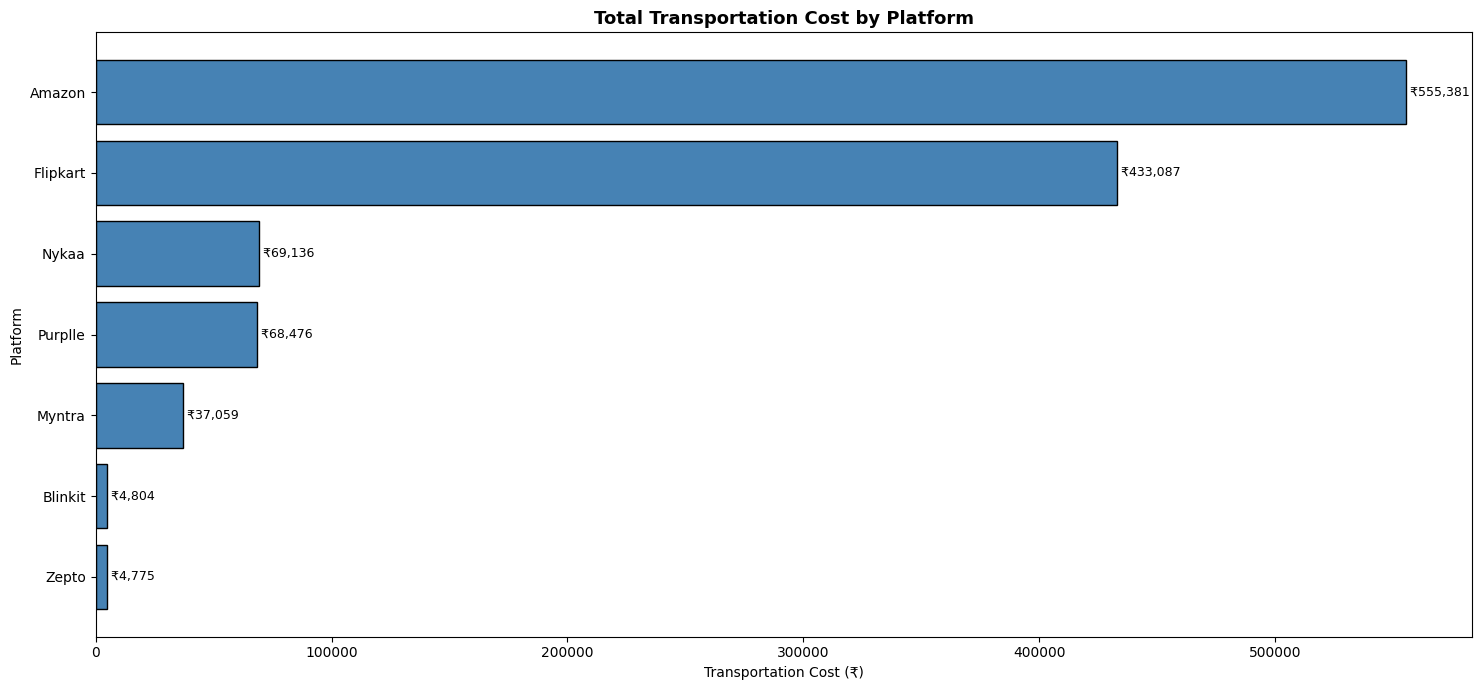

In [11]:
plt.figure(figsize=(15, 7))

plt.barh(q1.index, q1['Total_Transport_Cost'],
         color='steelblue', edgecolor='black')

plt.title('Total Transportation Cost by Platform',
          fontsize=13, fontweight='bold')
plt.xlabel('Transportation Cost (₹)')
plt.ylabel('Platform')
plt.gca().invert_yaxis()

for i, (platform, row) in enumerate(q1.iterrows()):
    plt.text(row['Total_Transport_Cost'], i,
             f" ₹{row['Total_Transport_Cost']:,.0f}",
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig('q1_transport_cost.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
q2 = df.groupby('Platform').agg(
    Orders=('Order ID', 'count'),
    Sticker_Required=('Stickering Requirement (Y/N)', lambda x: (x == 'Y').sum()),
    Total_Stickering_Cost=('Stickering Cost (₹)', 'sum'),
    Adhered=('Appointment Adherence (Y/N)', lambda x: (x == 'Y').sum()),
    Total_Penalty=('Penalty Cost (₹)', 'sum')
).round(2)

q2['Adherence_%'] = (q2['Adhered'] / q2['Orders'] * 100).round(1)
q2 = q2.sort_values('Adherence_%')
q2

,Orders,Sticker_Required,Total_Stickering_Cost,Adhered,Total_Penalty,Adherence_%
Platform,,,,,,
Blinkit,11,0,0,3,12254,27.3
Zepto,10,0,0,3,22698,30.0
Flipkart,13,0,0,5,31896,38.5
Myntra,12,0,0,6,15461,50.0
Purplle,18,0,0,9,28109,50.0
Nykaa,21,0,0,11,19952,52.4
Amazon,15,15,1184388,8,12858,53.3


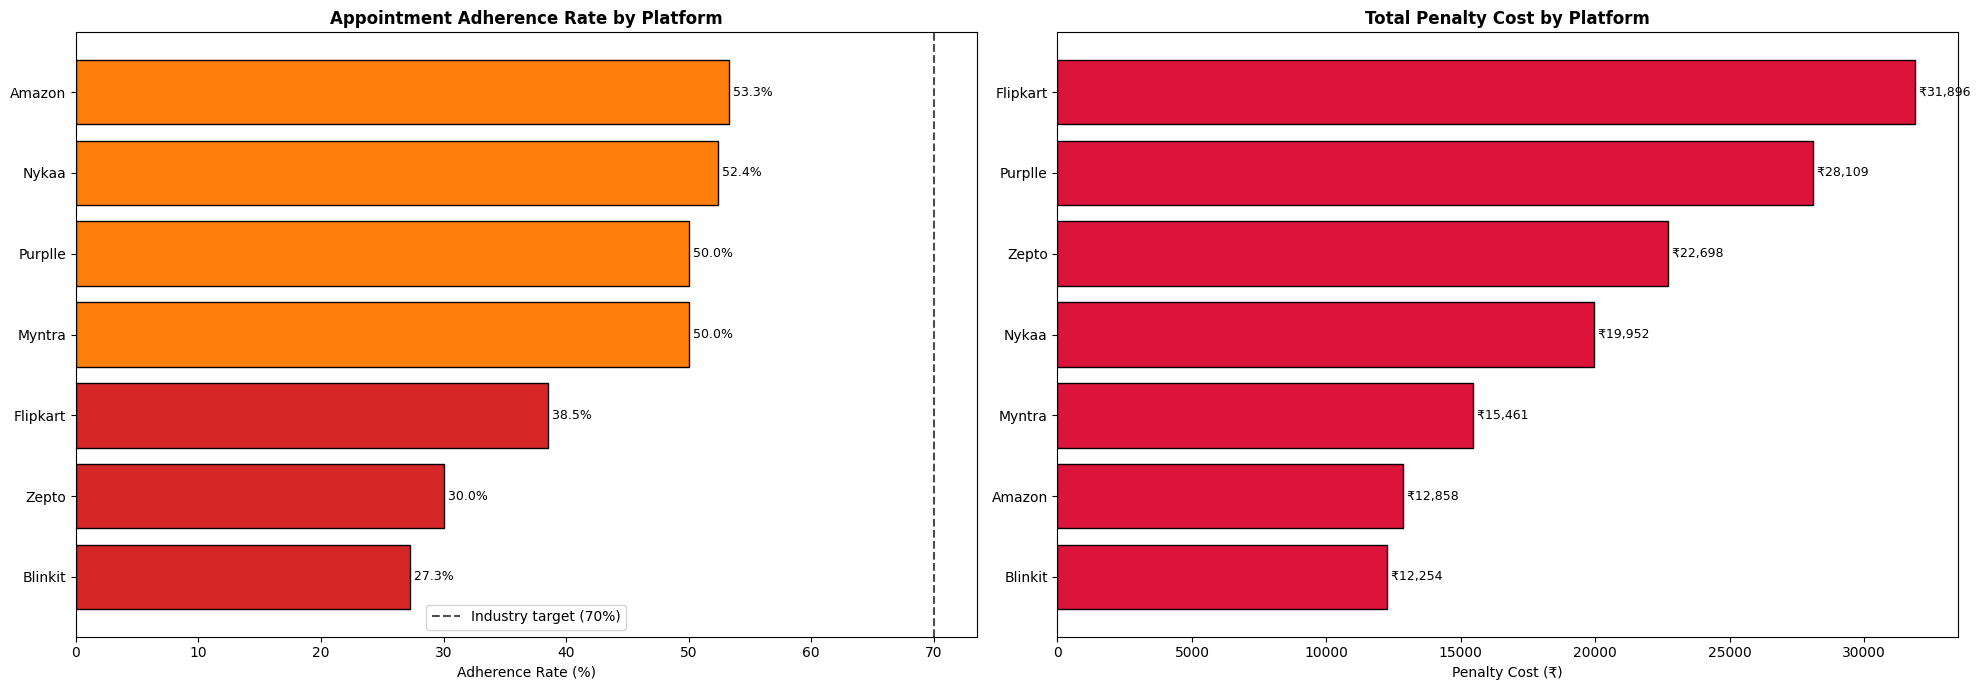

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Chart 1 — Adherence % per platform
adherence_sorted = q2['Adherence_%'].sort_values()
colors = ['#d62728' if x < 40 else '#ff7f0e' if x < 60 else '#2ca02c'
          for x in adherence_sorted]

axes[0].barh(adherence_sorted.index, adherence_sorted.values,
             color=colors, edgecolor='black')
axes[0].axvline(x=70, color='black', linestyle='--',
                alpha=0.7, label='Industry target (70%)')
axes[0].set_title('Appointment Adherence Rate by Platform',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Adherence Rate (%)')
axes[0].legend()

for i, v in enumerate(adherence_sorted.values):
    axes[0].text(v, i, f' {v}%', va='center', fontsize=9)

# Chart 2 — Penalty cost per platform
penalty_sorted = q2['Total_Penalty'].sort_values()
axes[1].barh(penalty_sorted.index, penalty_sorted.values,
             color='crimson', edgecolor='black')
axes[1].set_title('Total Penalty Cost by Platform',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Penalty Cost (₹)')

for i, v in enumerate(penalty_sorted.values):
    axes[1].text(v, i, f' ₹{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('q2_adherence_penalty.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
q3 = df.groupby('Warehouse Location').agg(
    Orders=('Order ID', 'count'),
    Total_Units=('Order Units', 'sum'),
    Total_Weight=('Order Weight (kgs)', 'sum'),
    Total_Cost=('Total Logistics Cost (₹)', 'sum')
).round(2)

q3['Order_Share_%'] = (q3['Orders'] / q3['Orders'].sum() * 100).round(1)
q3['Volume_Share_%'] = (q3['Total_Units'] / q3['Total_Units'].sum() * 100).round(1)
q3['Cost_per_Unit'] = (q3['Total_Cost'] / q3['Total_Units']).round(3)
q3 = q3.sort_values('Total_Units', ascending=False)
q3

,Orders,Total_Units,Total_Weight,Total_Cost,Order_Share_%,Volume_Share_%,Cost_per_Unit
Warehouse Location,,,,,,,
Delhi,38,347793,34370.12,906253.17,38.0,37.6,2.606
Mumbai,28,315549,32556.81,936846.96,28.0,34.1,2.969
Bangalore,34,261550,26670.48,657232.87,34.0,28.3,2.513


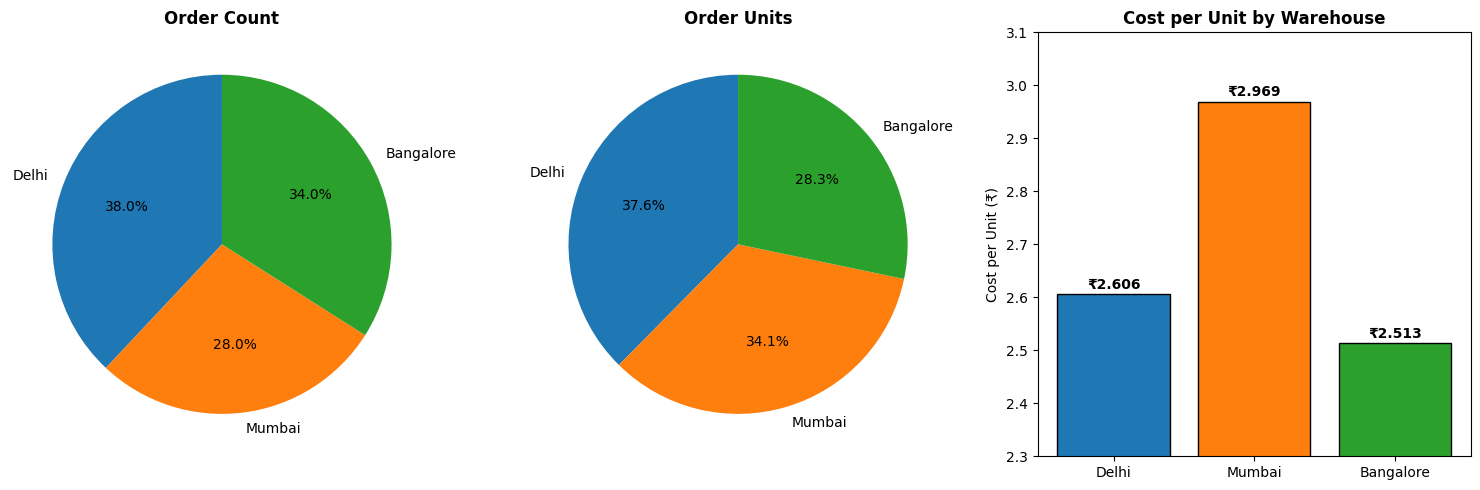

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

warehouses = q3.index.tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Chart 1 — Order count distribution
axes[0].pie(q3['Orders'], labels=warehouses,
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Order Count', fontweight='bold', fontsize=12)

# Chart 2 — Volume (units) distribution
axes[1].pie(q3['Total_Units'], labels=warehouses,
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Order Units', fontweight='bold', fontsize=12)

# Chart 3 — Cost per unit comparison
axes[2].bar(warehouses, q3['Cost_per_Unit'],
            color=colors, edgecolor='black')
axes[2].set_title('Cost per Unit by Warehouse',
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('Cost per Unit (₹)')
axes[2].set_ylim(2.3, 3.1)

for i, v in enumerate(q3['Cost_per_Unit']):
    axes[2].text(i, v + 0.01, f'₹{v:.3f}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('q3_warehouse.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
import datetime

today = pd.Timestamp('2025-01-01')

# Filter only orders that need stickering
sticker = df[df['Stickering Requirement (Y/N)'] == 'Y'].copy()

# Convert appointment date to datetime
sticker['Appointment Date'] = pd.to_datetime(sticker['Appointment Date'])

# Days available from today to appointment
sticker['Days_Available'] = (sticker['Appointment Date'] - today).dt.days

# Total stickering minutes needed per order
sticker['Stickering_Minutes'] = sticker['Order Units'] * 2

# Minutes one worker can do per day (2 shifts × 8 hours × 60 min)
MINUTES_PER_WORKER_PER_DAY = 2 * 8 * 60

# Workers needed per order (rounded up)
sticker['Workers_Needed'] = np.ceil(
    sticker['Stickering_Minutes'] /
    (sticker['Days_Available'] * MINUTES_PER_WORKER_PER_DAY)
).astype(int)

sticker[['Order ID', 'Order Units', 'Appointment Date',
         'Days_Available', 'Stickering_Minutes', 'Workers_Needed']].sort_values(
         'Workers_Needed', ascending=False)

,Order ID,Order Units,Appointment Date,Days_Available,Stickering_Minutes,Workers_Needed
85,O00086,47256,2025-01-10,9,94512,11
74,O00075,24890,2025-01-11,10,49780,6
47,O00048,44121,2025-01-21,20,88242,5
84,O00085,41535,2025-01-20,19,83070,5
94,O00095,30140,2025-01-18,17,60280,4
43,O00044,42284,2025-01-30,29,84568,4
36,O00037,39663,2025-01-24,23,79326,4
97,O00098,27320,2025-01-19,18,54640,4
66,O00067,22416,2025-01-24,23,44832,3
53,O00054,31408,2025-01-29,28,62816,3


In [17]:
date_range = pd.date_range('2025-01-01', sticker['Appointment Date'].max())

daily = []

for current_date in date_range:

    active = sticker[sticker['Appointment Date'] >= current_date].copy()

    active['Days_Remaining'] = (active['Appointment Date'] - current_date).dt.days
    active['Days_Remaining'] = active['Days_Remaining'].replace(0, 1)

    active['Workers_Today'] = np.ceil(
        active['Stickering_Minutes'] /
        (active['Days_Remaining'] * MINUTES_PER_WORKER_PER_DAY)
    ).astype(int)

    daily.append({
        'Date': current_date,
        'Active_Orders': len(active),
        'Workers_Needed': active['Workers_Today'].sum()
    })

q4_daily = pd.DataFrame(daily)
q4_daily.head(15)

,Date,Active_Orders,Workers_Needed
0,2025-01-01,15,57
1,2025-01-02,15,60
2,2025-01-03,15,66
3,2025-01-04,15,71
4,2025-01-05,15,76
5,2025-01-06,15,87
6,2025-01-07,15,98
7,2025-01-08,15,130
8,2025-01-09,15,196
9,2025-01-10,15,226


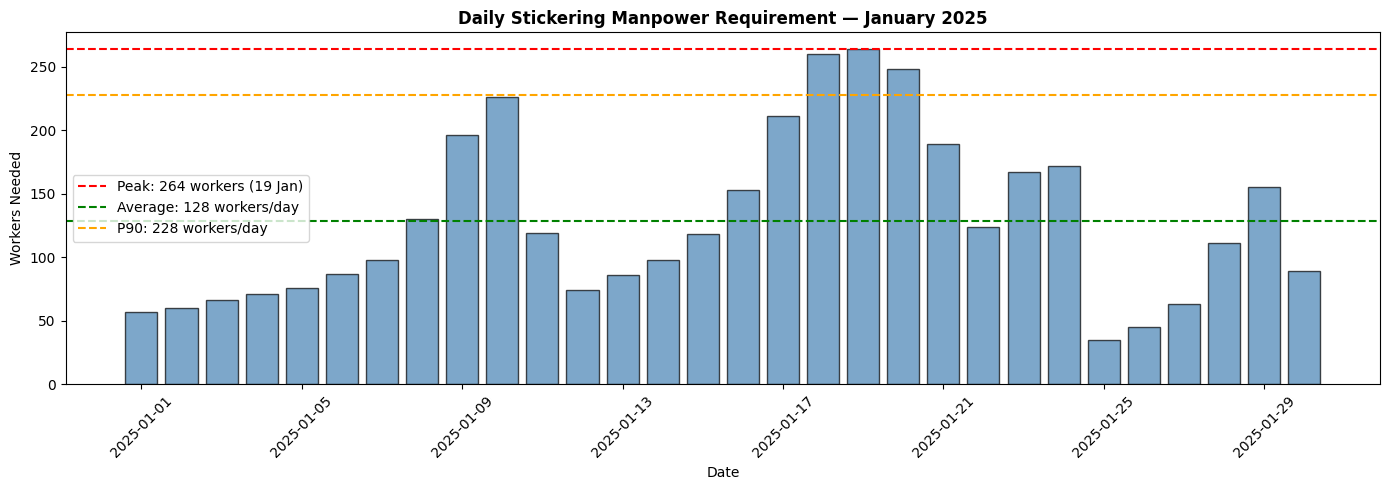


Peak workers needed:   264 on 19 Jan
Average workers/day:   128
P90 workers/day:       228


In [18]:
plt.figure(figsize=(14, 5))

plt.bar(q4_daily['Date'], q4_daily['Workers_Needed'],
        color='steelblue', edgecolor='black', alpha=0.7)

peak_idx = q4_daily['Workers_Needed'].idxmax()
peak_date = q4_daily.loc[peak_idx, 'Date']
peak_workers = q4_daily.loc[peak_idx, 'Workers_Needed']

avg_workers = q4_daily['Workers_Needed'].mean()
p90_workers = q4_daily['Workers_Needed'].quantile(0.90)

plt.axhline(y=peak_workers, color='red', linestyle='--',
            label=f'Peak: {peak_workers} workers ({peak_date.strftime("%d %b")})')
plt.axhline(y=avg_workers, color='green', linestyle='--',
            label=f'Average: {avg_workers:.0f} workers/day')
plt.axhline(y=p90_workers, color='orange', linestyle='--',
            label=f'P90: {p90_workers:.0f} workers/day')

plt.title('Daily Stickering Manpower Requirement — January 2025',
          fontweight='bold', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Workers Needed')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('q4_manpower.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nPeak workers needed:   {peak_workers} on {peak_date.strftime('%d %b')}")
print(f"Average workers/day:   {avg_workers:.0f}")
print(f"P90 workers/day:       {p90_workers:.0f}")

In [19]:
print("=" * 60)
print("LOGISTICS COST ANALYSIS — SUMMARY")
print("=" * 60)
print(f"\nTotal Orders Analyzed: {len(df)}")
print(f"Total Logistics Cost:  ₹{df['Total Logistics Cost (₹)'].sum():,.0f}")
print(f"\nCost Breakdown:")
print(f"  Transportation: ₹{df['Transportation Cost (₹)'].sum():,.0f} (47%)")
print(f"  Stickering:     ₹{df['Stickering Cost (₹)'].sum():,.0f} (47%)")
print(f"  Penalties:      ₹{df['Penalty Cost (₹)'].sum():,.0f} (6%)")
print(f"\nKey Metrics:")
print(f"  Overall adherence rate: {(df['Appointment Adherence (Y/N)'] == 'Y').mean()*100:.1f}%")
print(f"  Most expensive platform (transport): Amazon ₹5,55,381")
print(f"  Most expensive warehouse (per unit): Mumbai ₹2.969")
print(f"  Peak stickering manpower needed:     264 workers (Jan 19)")
print(f"  Recommended permanent headcount:     228 workers (P90)")
print(f"\nEstimated Monthly Savings Opportunity: ₹1.54L – ₹2.40L")
print(f"Estimated Annual Savings Opportunity:  ₹18.5L – ₹28.8L")
print("=" * 60)

LOGISTICS COST ANALYSIS — SUMMARY

Total Orders Analyzed: 100
Total Logistics Cost:  ₹2,500,333

Cost Breakdown:
  Transportation: ₹1,172,717 (47%)
  Stickering:     ₹1,184,388 (47%)
  Penalties:      ₹143,228 (6%)

Key Metrics:
  Overall adherence rate: 45.0%
  Most expensive platform (transport): Amazon ₹5,55,381
  Most expensive warehouse (per unit): Mumbai ₹2.969
  Peak stickering manpower needed:     264 workers (Jan 19)
  Recommended permanent headcount:     228 workers (P90)

Estimated Monthly Savings Opportunity: ₹1.54L – ₹2.40L
Estimated Annual Savings Opportunity:  ₹18.5L – ₹28.8L


In [23]:
from google.colab import files

files.download('q1_transport_cost.png')
files.download('q2_adherence_penalty.png')
files.download('q3_warehouse.png')
files.download('q4_manpower.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import os
pngs = [f for f in os.listdir('.') if f.endswith('.png')]
print("PNG files available:", pngs)

PNG files available: ['q4_manpower.png', 'q3_warehouse.png', 'q1_transport_cost.png', 'q2_adherence_penalty.png']
